In [1]:
!pip install qiskit matplotlib numpy pylatexenc qiskit-aer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.9 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=ae44af131086b5a8ba7b761bb6098a7256848bcb91bd40279738111e934f4b59
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import *
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from IPython.display import display



# 3-Qubit Bit-Flip Code

Arbitrary State:
$$ |\psi\rangle = \alpha |0\rangle + \beta |1\rangle $$

We convert this above state i.e physical state into logical state (below):

$$ |\psi_{L}\rangle = \alpha |000\rangle + \beta |111\rangle $$

With the help of Qiskit we built the circuit. Run the below code:


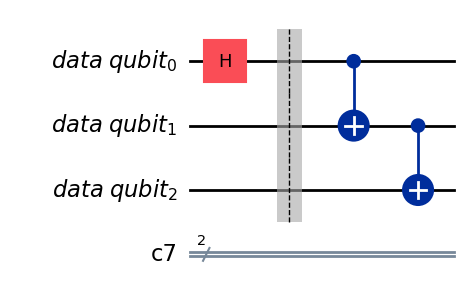

In [ ]:
qr1 = QuantumRegister(3,'data qubit')
cr1= ClassicalRegister(2)
circuit1 = QuantumCircuit(qr1,cr1)

# ======== Put qubit 0 into a superposition ======= #
# We want to protect this state from errors
circuit1.h(qr1[0])
circuit1.barrier()

# ======== Prepare the logical qubit ======= #
# cx = CNOT gates
# cx(control qubit, target qubit)
circuit1.cx(qr1[0],qr1[1]) # CNOT on qubit 0 and qubit 1
circuit1.cx(qr1[1],qr1[2]) # CNOT on qubit 1 and qubit 2
circuit1.draw(output='mpl')

# A bit-flip error on physical qubit 1 would look like this:

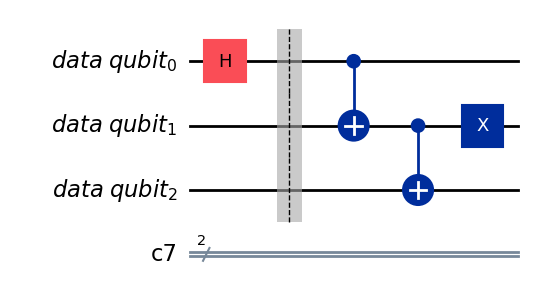

In [ ]:
# x is the bit-flip operator, applied on qubit 1
circuit1.x(qr1[1])
circuit1.draw(output='mpl')

# When a bit-flip error occurs on physical qubit 1, the state is changed to:

**Before error:**
$$|\psi_{L}\rangle = \alpha |000\rangle + \beta |111\rangle$$

**After X gate on qubit 1:**
$$|\psi_{L}\rangle \rightarrow \alpha |010\rangle + \beta |101\rangle$$

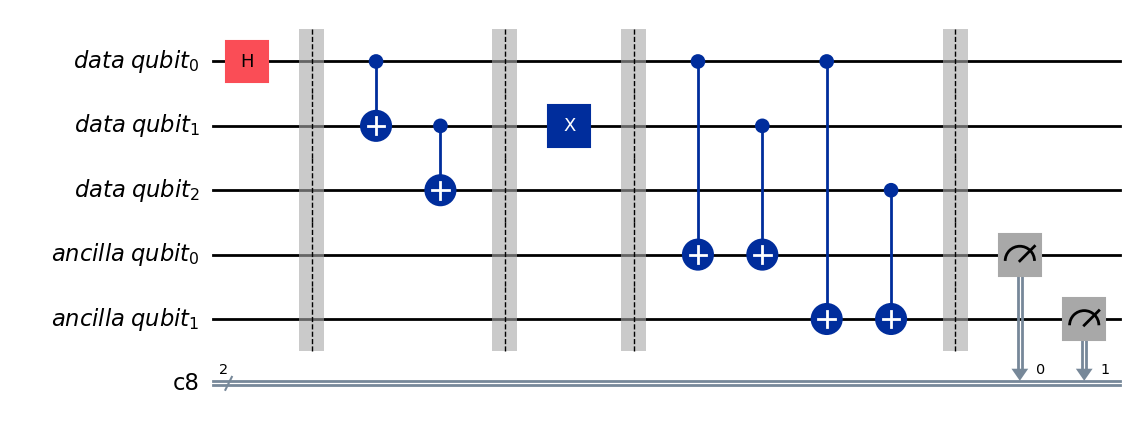

In [ ]:
qr2 = QuantumRegister(3,'data qubit')
ar2 = QuantumRegister(2,'ancilla qubit')
cr2 = ClassicalRegister(2)

circuit2 = QuantumCircuit(qr2,ar2,cr2)

# ======== The original state ======= #

circuit2.h(qr2[0])
circuit2.barrier()

# ======== Prepare the logical qubit ======= #

circuit2.cx(qr2[0],qr2[1])
circuit2.cx(qr2[1],qr2[2])

circuit2.barrier()

# ======== Bit-flip Error on qubit 1 ======= #
circuit2.x(qr2[1])

circuit2.barrier()
# ======== We need to add Ancilla qubits, which we can measure, based on their values we can detect if a bit-flip error occured and which qubit was flipped ======= #

circuit2.cx(qr2[0],ar2[0])
circuit2.cx(qr2[1],ar2[0])
circuit2.cx(qr2[0],ar2[1])
circuit2.cx(qr2[2],ar2[1])


circuit2.barrier()

## ======Measure the ancilla qubits =========== ###

circuit2.measure(ar2[0],cr2[0])
circuit2.measure(ar2[1],cr2[1])

fig = circuit2.draw(output='mpl')
display(fig)
plt.close()
circuit2.barrier();

Let's go through the circuit to see how the quantum state changes and which measurement outcome we expect:

This is the state after the error, the ancilla qubits are still in state $|00\rangle_{a}$:

$$|\psi_{L}\rangle |00\rangle_{a} = (\alpha |000\rangle + \beta |111\rangle) |00\rangle_{a} \xrightarrow{\text{X on data qubit 1}} (\alpha |010\rangle + \beta |101\rangle) |00\rangle_{a}$$

(<b>Reminder:</b> CNOT gate flips the target qubit if the control qubit is in the $|1\rangle$ state. For a CNOT where qubit 0 is control, qubit 1 is target:

CNOT(control, target) = CNOT(qubit 0, qubit 1): $|00\rangle \rightarrow |00\rangle$, $|01\rangle \rightarrow |01\rangle$, $|10\rangle \rightarrow |11\rangle$, $|11\rangle \rightarrow |10\rangle$)

Let's entangle the ancilla qubits with the data qubits:

$$(\alpha |010\rangle + \beta |101\rangle) |00\rangle_{a} \xrightarrow{\text{CNOT(data 0, ancilla 0)}} \alpha |010\rangle |00\rangle_{a} + \beta |101\rangle |10\rangle_{a}$$

$$\alpha |010\rangle |00\rangle_{a} + \beta |101\rangle |10\rangle_{a} \xrightarrow{\text{CNOT(data 1, ancilla 0)}} \alpha |010\rangle |10\rangle_{a} + \beta |101\rangle |10\rangle_{a}$$

$$\alpha |010\rangle |10\rangle_{a} + \beta |101\rangle |10\rangle_{a} \xrightarrow{\text{CNOT(data 0, ancilla 1)}} \alpha |010\rangle |10\rangle_{a} + \beta |101\rangle |11\rangle_{a}$$

$$\alpha |010\rangle |10\rangle_{a} + \beta |101\rangle |11\rangle_{a} \xrightarrow{\text{CNOT(data 2, ancilla 1)}} \alpha |010\rangle |10\rangle_{a} + \beta |101\rangle |10\rangle_{a}$$

The state before measuring is:

$$\alpha |010\rangle |10\rangle_{a} + \beta |101\rangle |10\rangle_{a} = (\alpha |010\rangle + \beta |101\rangle) |10\rangle_{a}$$

When measuring the ancilla qubits, ancilla qubit 0 should be in the $|1\rangle$ state and ancilla qubit 1 should be in the $|0\rangle$ state.

Let's check this by measuring (in Qiskit the bit ordering is: Ancilla_bit_1 | Ancilla_bit_0):

In [ ]:
aer_sim = AerSimulator()
transpiled_circuit2 = transpile(circuit2, aer_sim)
results = aer_sim.run(transpiled_circuit2, shots=1).result()
answer = list(results.get_counts())[0]

print("Measurement outcome is: Ancilla_bit_1, Ancilla_bit_0 =", answer)

Measurement outcome is: Ancilla_bit_1, Ancilla_bit_0 = 01


Now that we know that a bit-flip error on qubit 1 has occured, we can correct it by flipping it back to it original value by applying a X-gate on qubit 1:

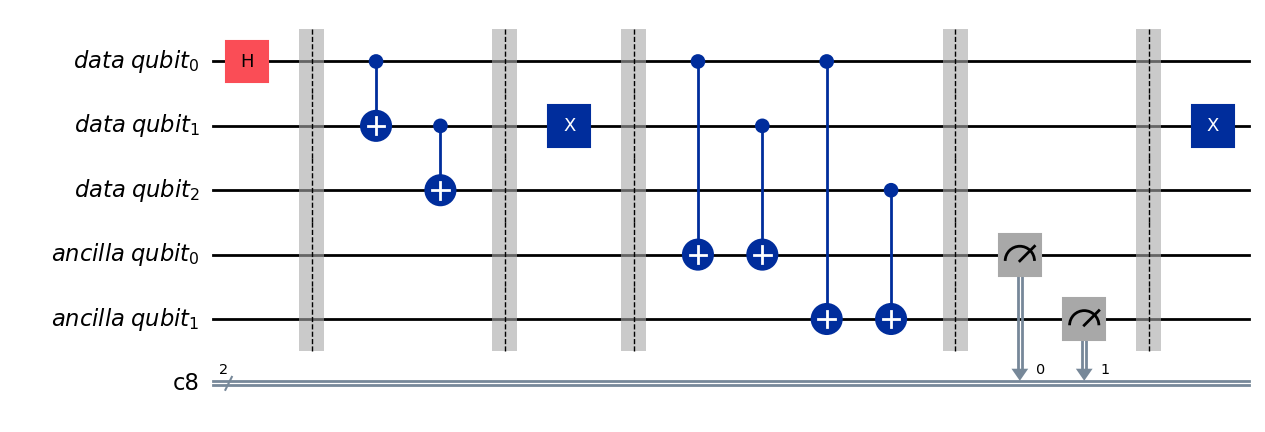

In [ ]:
circuit2.x(qr1[1])
circuit2.draw(output='mpl')

Lets apply a random bit-flip error on a qubit, and lets see what measurement outcomes we get:

In [ ]:
# ======== This is our random error model ======= #

def error_model(qr):
    error_model = QuantumCircuit(qr)
    output = np.random.randint(3)
    error_model.x(qr[output])
    #print(output)
    #error_model.draw(output='mpl')
    error_gate = error_model.to_gate()
    error_gate.name = "Bit Flip Error"
    return error_gate

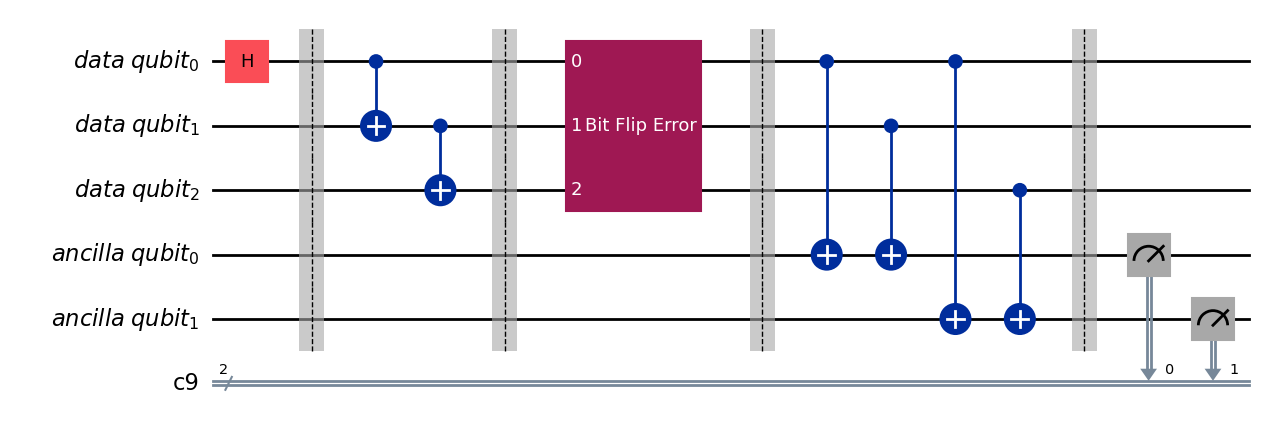

Measurement outcome is: Ancilla_bit_1, Ancilla_bit_0 = 01


In [ ]:
qr3 = QuantumRegister(3,'data qubit')
ar3 = QuantumRegister(2,'ancilla qubit')
cr3 = ClassicalRegister(2)

circuit3 = QuantumCircuit(qr3,ar3,cr3)

circuit3.h(qr3[0])
circuit3.barrier()

circuit3.cx(qr3[0],qr3[1])
circuit3.cx(qr3[1],qr3[2])

circuit3.barrier()

error_gate_model = error_model(qr3)

circuit3.append(error_gate_model,range(3))
circuit3.barrier()
# ======== We need to add Ancilla bits to measure the syndrome ======= #

circuit3.cx(qr3[0],ar3[0])
circuit3.cx(qr3[1],ar3[0])
circuit3.cx(qr3[0],ar3[1])
circuit3.cx(qr3[2],ar3[1])

circuit3.barrier()

## ======Measure from the ancilla bits =========== ###

circuit3.measure(ar3[0],cr3[0])
circuit3.measure(ar3[1],cr3[1])


fig = circuit3.draw(output='mpl')
display(fig)
plt.close()

#circuit3.barrier()

#aer_sim = Aer.get_backend('qasm_simulator')
#transpiled_circuit3 = transpile(circuit3, aer_sim)
#qobj = assemble(transpiled_circuit3,shots=1)
#results = aer_sim.run(qobj).result()
#answer = results.get_counts()

aer_sim = AerSimulator()
transpiled_circuit2 = transpile(circuit2, aer_sim)
results = aer_sim.run(transpiled_circuit2, shots=1).result()
answer = results.get_counts()

#display(plot_histogram(answer))
print("=============================================")
print("Measurement outcome is: Ancilla_bit_1, Ancilla_bit_0 =",list(answer.keys())[0])
print("=============================================");


# Task:

Based on the measurement outcome, can you correct the error?

# Question:
Which measurement outcomes indicate which bit-flip error?

(for the solution go to the end of this notebook)

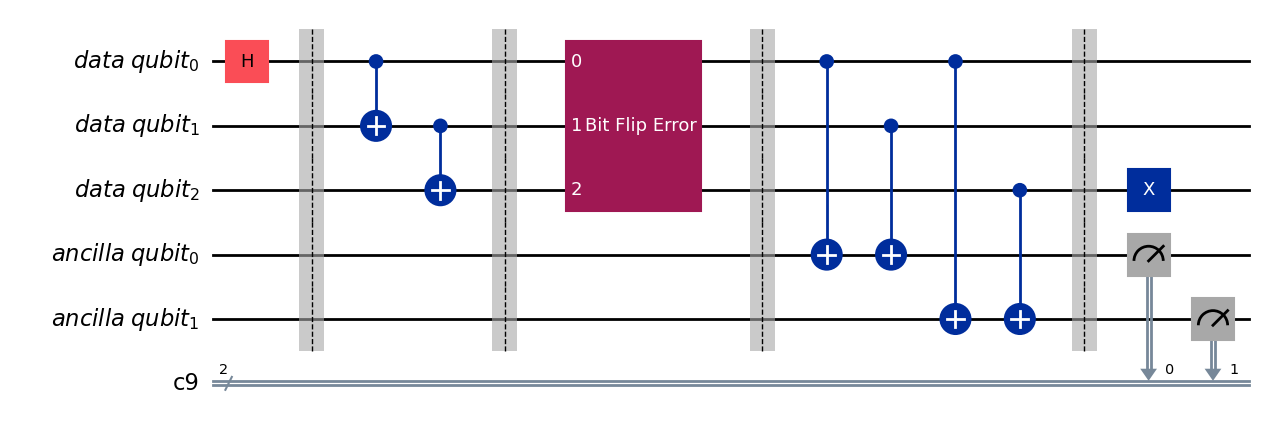

Error has NOT been corrected
final data qubit state = 


<IPython.core.display.Latex object>

In [ ]:
# ======== Change here the qubit index ======= #
correct_qubit = 2 # 0, 1, 2 ???

circuit3.x(qr3[correct_qubit])


fig = circuit3.draw(output='mpl')
display(fig)
plt.close()


circuit_no_measure = circuit3.remove_final_measurements(inplace=False)
state = Statevector.from_instruction(circuit_no_measure)

data = np.linalg.svd(state.data.reshape(4, -1))[2][0]
data = data * np.sign(data[np.argmax(np.abs(data))].real)  # Fix sign


if Statevector(data / np.linalg.norm(data)).reverse_qargs().draw('latex_source') in [' |000\\rangle', '\\frac{\\sqrt{2}}{2} |000\\rangle+\\frac{\\sqrt{2}}{2} |111\\rangle']:
    print("=============================================")
    print('Congratulations!!!')
    print('Error has been corrected')
    print("=============================================")

else:
    print("=============================================")
    print('Error has NOT been corrected')
    print("=============================================")

print('final data qubit state = ')
Statevector(data / np.linalg.norm(data)).reverse_qargs().draw('latex')


# 3-Qubit Phase Flip Code

## What is a Phase Flip Error?

A **phase flip error** is caused by the Z gate (Pauli-Z). Unlike a bit-flip error (X gate) which flips $|0\rangle \leftrightarrow |1\rangle$, a phase flip adds a negative sign to the $|1\rangle$ component:

$$Z|0\rangle = |0\rangle$$
$$Z|1\rangle = -|1\rangle$$

For a general superposition state:

$$Z(\alpha|0\rangle + \beta|1\rangle) = \alpha|0\rangle - \beta|1\rangle$$

The probabilities of measuring $|0\rangle$ or $|1\rangle$ remain the same, but the **relative phase** between them changes. This is why phase errors are harder to detect in the computational (Z) basis.

---

## The |+⟩ and |−⟩ States (X-Basis)

The $|+\rangle$ and $|-\rangle$ states are superposition states created by applying the Hadamard gate:

$$|+\rangle = H|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$$

$$|-\rangle = H|1\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$$

These states form the **X-basis** (also called Hadamard basis), as opposed to the **Z-basis** ($|0\rangle$, $|1\rangle$).

| Basis | States | Measurement |
|-------|--------|-------------|
| Z-basis (computational) | $\|0\rangle$, $\|1\rangle$ | Standard measurement |
| X-basis (Hadamard) | $\|+\rangle$, $\|-\rangle$ | Apply H, then measure |

---

## Why Phase Flip Looks Like Bit Flip in X-Basis

Here's the key insight: a **phase flip (Z) in the Z-basis** acts like a **bit flip in the X-basis**:

$$Z|+\rangle = Z \cdot \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle) = |-\rangle$$

$$Z|-\rangle = Z \cdot \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle) = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) = |+\rangle$$

So a Z gate flips $|+\rangle \leftrightarrow |-\rangle$, just like an X gate flips $|0\rangle \leftrightarrow |1\rangle$.

---

## Summary Table

| Error Type | Gate | Effect in Z-basis | Effect in X-basis |
|------------|------|-------------------|-------------------|
| Bit flip | X | $\|0\rangle \leftrightarrow \|1\rangle$ | Phase change |
| Phase flip | Z | Phase change | $\|+\rangle \leftrightarrow \|-\rangle$ |

This is why the 3-Qubit Phase Flip Code uses the same structure as the Bit Flip Code, but with Hadamard gates to switch between bases.

Like already mentioned if we sandwich the bit-flip errors encountered in the Bit-flip code between Hadamards, then the error becomes a phase flip error. Hence, the encoding for this state just becomes taking the encoded state of the bit-flip code through a wall of Hadamards. Therefore,

<b>Encoding:</b>

$$|\psi_{L}\rangle = \alpha |+++\rangle + \beta |---\rangle$$

Note that to detect phase flip errors we will need a measurement in the X-basis. In the bit-flip case the measurement was in the Z-basis.

Based on these considerations and the simple fact that $HZH = X$ and $H^2 = I$, we construct the following circuit for the 3-Qubit Phase Flip Code in analogy with its bit-flip counterpart.

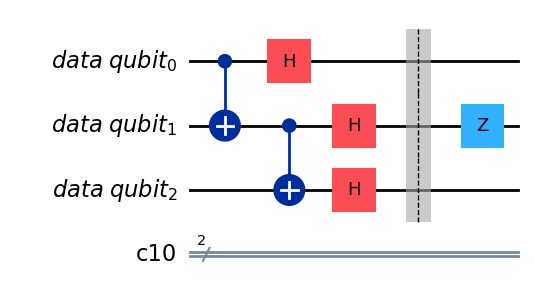

In [ ]:
qr2 = QuantumRegister(3,'data qubit')
cr2 = ClassicalRegister(2)

circuit2 = QuantumCircuit(qr2,cr2)

circuit2.cx(qr2[0],qr2[1])
circuit2.cx(qr2[1],qr2[2])
circuit2.h(qr2)
circuit2.barrier()


circuit2.z(qr2[1])

state = Statevector.from_instruction(circuit2)
circuit2.draw(output='mpl')


After this error the state should be $$|\psi_{L}\rangle = \alpha |+-+\rangle + \beta |-+-\rangle$$

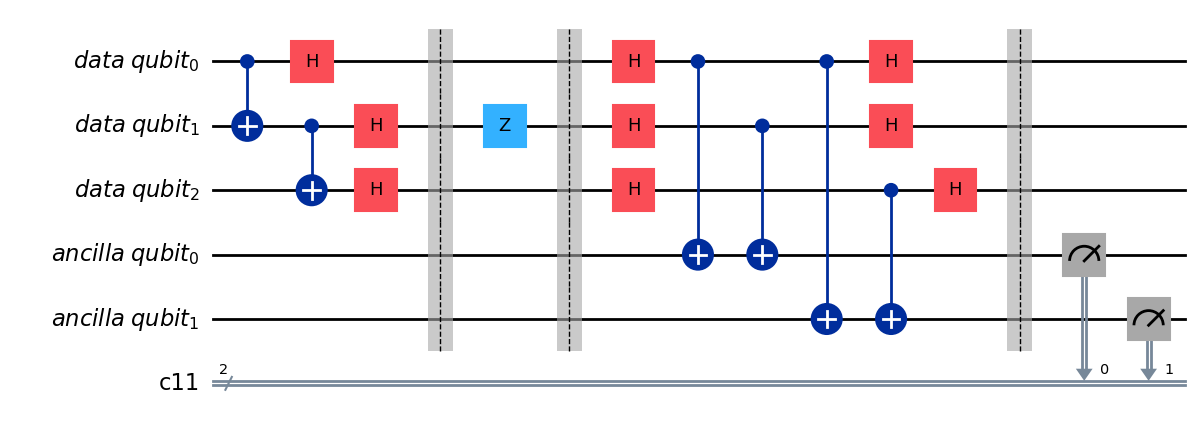

In [ ]:
qr2 = QuantumRegister(3,'data qubit')
ar2 = QuantumRegister(2,'ancilla qubit')
cr2 = ClassicalRegister(2)

circuit2 = QuantumCircuit(qr2,ar2,cr2)

circuit2.cx(qr2[0],qr2[1])
circuit2.cx(qr2[1],qr2[2])
circuit2.h(qr2)
circuit2.barrier()


circuit2.z(qr2[1])

circuit2.barrier()



# ======== We need to entangle the Physical bits with the Ancilla bits in a certain manner to measure the syndrome. ======= #

# ======== The contact points between the two registers are sandwiched between hadamards because the eventual ======= #
# ======== measurement of the Ancilla bits will be in the Z bases and we want to measure in the X bases. The Hadamards make that conversion======= #
circuit2.h(qr2)
circuit2.cx(qr2[0],ar2[0])
circuit2.cx(qr2[1],ar2[0])
circuit2.cx(qr2[0],ar2[1])
circuit2.cx(qr2[2],ar2[1])
circuit2.h(qr2)
circuit2.barrier()

## ======Measure from the ancilla bits =========== ###

circuit2.measure(ar2[0],cr2[0])
circuit2.measure(ar2[1],cr2[1])


circuit2.draw(output='mpl')

Let's go through the circuit to see how the quantum state changes and which measurement outcome we expect:

## Initial Encoded State

The logical qubit is encoded in the X-basis:

$$|\psi_{L}\rangle |00\rangle_{a} = (\alpha |+++\rangle + \beta |---\rangle) |00\rangle_{a}$$

## Phase Flip Error

A phase flip error (Z gate) on data qubit 1 flips $|+\rangle \leftrightarrow |-\rangle$:

$$(\alpha |+++\rangle + \beta |---\rangle) |00\rangle_{a} \xrightarrow{\text{Z on data qubit 1}} (\alpha |+-+\rangle + \beta |-+-\rangle) |00\rangle_{a}$$

(<b>Reminder:</b> The Z gate acts on X-basis states as:
$Z|+\rangle = |-\rangle$ and $Z|-\rangle = |+\rangle$)

## Convert to Z-Basis for Syndrome Measurement

To detect the error, we apply Hadamard gates to convert from X-basis to Z-basis:

$$H|+\rangle = |0\rangle \quad \text{and} \quad H|-\rangle = |1\rangle$$

$$(\alpha |+-+\rangle + \beta |-+-\rangle) |00\rangle_{a} \xrightarrow{\text{H on all data qubits}} (\alpha |010\rangle + \beta |101\rangle) |00\rangle_{a}$$

## Syndrome Extraction with CNOT Gates

Now we entangle the ancilla qubits with the data qubits (same as bit-flip code):

$$(\alpha |010\rangle + \beta |101\rangle) |00\rangle_{a} \xrightarrow{\text{CNOT(data 0, ancilla 0)}} \alpha |010\rangle |00\rangle_{a} + \beta |101\rangle |10\rangle_{a}$$

$$\alpha |010\rangle |00\rangle_{a} + \beta |101\rangle |10\rangle_{a} \xrightarrow{\text{CNOT(data 1, ancilla 0)}} \alpha |010\rangle |10\rangle_{a} + \beta |101\rangle |10\rangle_{a}$$

$$\alpha |010\rangle |10\rangle_{a} + \beta |101\rangle |10\rangle_{a} \xrightarrow{\text{CNOT(data 0, ancilla 1)}} \alpha |010\rangle |10\rangle_{a} + \beta |101\rangle |11\rangle_{a}$$

$$\alpha |010\rangle |10\rangle_{a} + \beta |101\rangle |11\rangle_{a} \xrightarrow{\text{CNOT(data 2, ancilla 1)}} \alpha |010\rangle |10\rangle_{a} + \beta |101\rangle |10\rangle_{a}$$

## State Before Measurement

$$\alpha |010\rangle |10\rangle_{a} + \beta |101\rangle |10\rangle_{a} = (\alpha |010\rangle + \beta |101\rangle) |10\rangle_{a}$$

When measuring the ancilla qubits, ancilla qubit 0 should be in the $|1\rangle$ state and ancilla qubit 1 should be in the $|0\rangle$ state.


Let's check this by measuring (in Qiskit the bit ordering is: Ancilla_bit_1 | Ancilla_bit_0):

In [ ]:
aer_sim = AerSimulator()
transpiled_circuit2 = transpile(circuit2, aer_sim)
results = aer_sim.run(transpiled_circuit2, shots=1).result()
answer = list(results.get_counts())[0]

print("Measurement outcome is: Ancilla_bit_1, Ancilla_bit_0 =", answer)

Measurement outcome is: Ancilla_bit_1, Ancilla_bit_0 = 01


Now that we know that a phase-flip error on qubit 1 has occured, we can correct it by flipping it back to it original value by applying a Z-gate on qubit 1,
 (Note: after entanglement with the ancilla qubits we convert back from Z-basis to X-basis with H-gates on all data qubits):

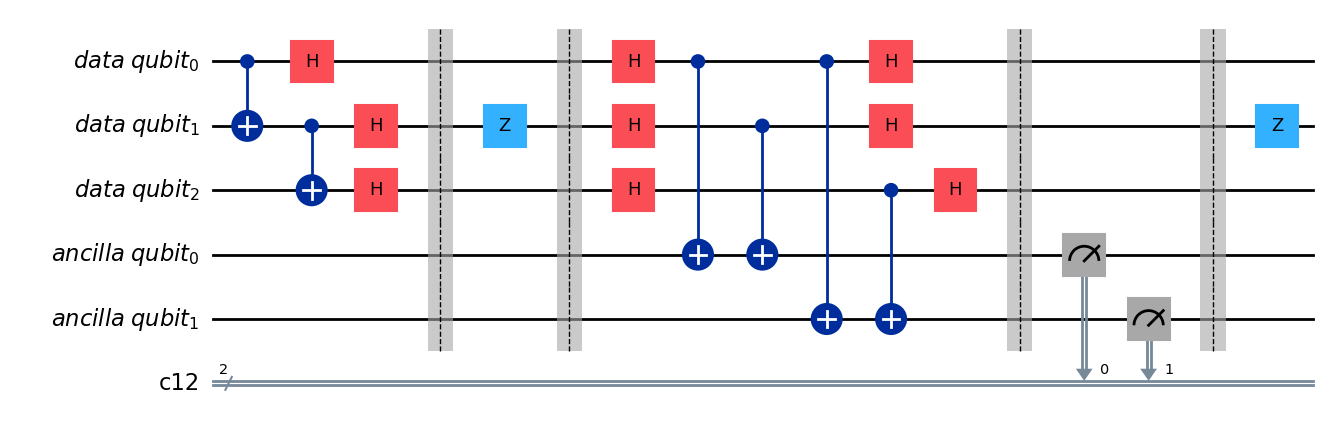

In [ ]:
qr2 = QuantumRegister(3,'data qubit')
ar2 = QuantumRegister(2,'ancilla qubit')
cr2 = ClassicalRegister(2)

circuit2 = QuantumCircuit(qr2,ar2,cr2)

circuit2.cx(qr2[0],qr2[1])
circuit2.cx(qr2[1],qr2[2])
circuit2.h(qr2)
circuit2.barrier()


circuit2.z(qr2[1])

circuit2.barrier()

# ======== We need to entangle the Physical bits with the Ancilla bits in a certain manner to measure the syndrome. ======= #

# ======== The contact points between the two registers are sandwiched between hadamards because the eventual ======= #
# ======== measurement of the Ancilla bits will be in the Z bases and we want to measure in the X bases. The Hadamards make that conversion======= #
circuit2.h(qr2)
circuit2.cx(qr2[0],ar2[0])
circuit2.cx(qr2[1],ar2[0])
circuit2.cx(qr2[0],ar2[1])
circuit2.cx(qr2[2],ar2[1])
circuit2.h(qr2)
circuit2.barrier()

## ======Measure from the ancilla bits =========== ###

circuit2.measure(ar2[0],cr2[0])
circuit2.measure(ar2[1],cr2[1])

circuit2.barrier()


circuit2.z(qr2[1])


circuit2.draw(output='mpl')

Lets apply a random phase-flip error on a qubit, and lets see what measurement outcomes we get:

In [ ]:
def error_model():
    output =0
    error_model = QuantumCircuit(qr2)
    output = np.random.randint(3)
    error_model.z(qr2[output])
    error_gate = error_model.to_gate()
    error_gate.name = "Phase Flip Error"
    return error_gate

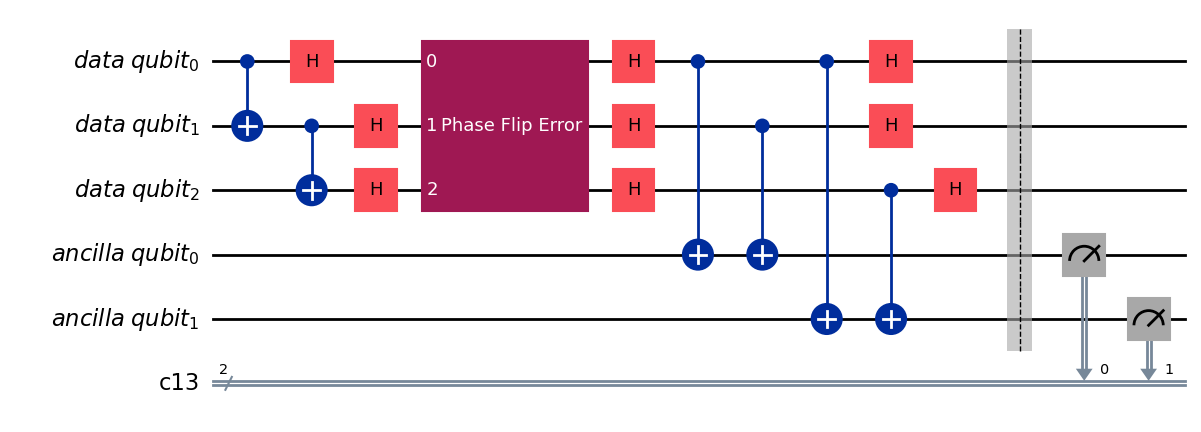

Measurement outcome is: Ancilla_bit_1, Ancilla_bit_0 = 01


In [ ]:
%matplotlib inline

qr3 = QuantumRegister(3,'data qubit')
ar3 = QuantumRegister(2,'ancilla qubit')
cr3 = ClassicalRegister(2)

circuit3 = QuantumCircuit(qr3,ar3,cr3)

circuit3.cx(qr3[0],qr3[1])
circuit3.cx(qr3[1],qr3[2])


error_gate_model = error_model()

circuit3.h(qr3)

circuit3.append(error_gate_model,range(3))

# ======== We need to entangle the Physical bits with the Ancilla bits in a certain manner to measure the syndrome. ======= #

# ======== The contact points between the two registers are sandwiched between hadamards because the eventual ======= #
# ======== measurement of the Ancilla bits will be in the Z bases and we want to measure in the X bases. The Hadamards make that conversion======= #
circuit3.h(qr3)
circuit3.cx(qr3[0],ar3[0])
circuit3.cx(qr3[1],ar3[0])
circuit3.cx(qr3[0],ar3[1])
circuit3.cx(qr3[2],ar3[1])
circuit3.h(qr3)
circuit3.barrier()

## ======Measure from the ancilla bits =========== ###

circuit3.measure(ar3[0],cr3[0])
circuit3.measure(ar3[1],cr3[1])


circuit3.draw(output='mpl')


fig = circuit3.draw(output='mpl')
display(fig)
plt.close()

#circuit3.barrier()

#aer_sim = Aer.get_backend('qasm_simulator')
#transpiled_circuit3 = transpile(circuit3, aer_sim)
#qobj = assemble(transpiled_circuit3,shots=1)
#results = aer_sim.run(qobj).result()
#answer = results.get_counts()

aer_sim = AerSimulator()
transpiled_circuit3 = transpile(circuit3, aer_sim)
results = aer_sim.run(transpiled_circuit3, shots=1).result()
answer = results.get_counts()

#display(plot_histogram(answer))
print("=============================================")
print("Measurement outcome is: Ancilla_bit_1, Ancilla_bit_0 =",list(answer.keys())[0])
print("=============================================");

# Task:

Based on the measurement outcome, can you correct the error?

# Question:
Which measurement outcomes indicate which phase-flip error? Is it the same as in the bit-flip case?

(for the solution go to the end of this notebook)

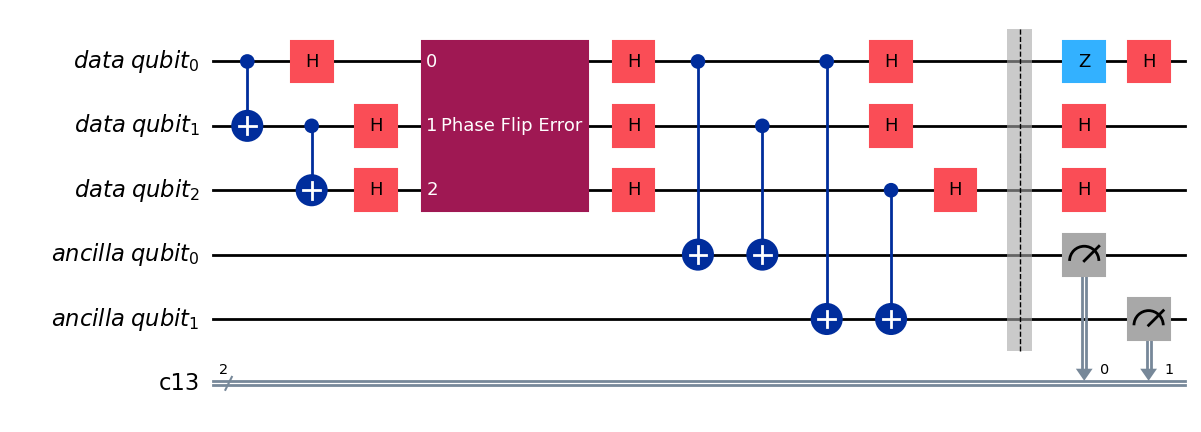

Error has NOT been corrected
final data qubit state = 


<IPython.core.display.Latex object>

In [ ]:
# ======== Change here the qubit index ======= #
correct_qubit = 0 # 0, 1, 2 ???

circuit3.z(qr3[correct_qubit])

# ======== added H gates on all data qubit to get the end state to be in computational basis again (|0> and |1>) ======= #
circuit3.h(qr3)
fig = circuit3.draw(output='mpl')
display(fig)
plt.close()



circuit_no_measure = circuit3.remove_final_measurements(inplace=False)
state = Statevector.from_instruction(circuit_no_measure)

data = np.linalg.svd(state.data.reshape(4, -1))[2][0]
data = data * np.sign(data[np.argmax(np.abs(data))].real)  # Fix sign


if Statevector(data / np.linalg.norm(data)).reverse_qargs().draw('latex_source') in [' |000\\rangle', '\\frac{\\sqrt{2}}{2} |000\\rangle+\\frac{\\sqrt{2}}{2} |111\\rangle']:
    print("=============================================")
    print('Congratulations!!!')
    print('Error has been corrected')
    print("=============================================")

else:
    print("=============================================")
    print('Error has NOT been corrected')
    print("=============================================")

print('final data qubit state = ')
Statevector(data / np.linalg.norm(data)).reverse_qargs().draw('latex')


# Solutions

## Syndrome Table for Bit Flip Code

| Ancilla_bit_1 | Ancilla_bit_0 | Error       |
|---------------|---------------|-------------|
| 0             | 0             | No Error    |
| 1             | 1             | data_bit_0  |
| 1             | 0             | data_bit_1  |
| 0             | 1             | data_bit_2  |

## Syndrome Table for Phase Flip Code

| Ancilla_bit_1 | Ancilla_bit_0 | Error          |
|---------------|---------------|----------------|
| 0             | 0             | No Error       |
| 1             | 1             | Z on data_bit_0 |
| 1             | 0             | Z on data_bit_1 |
| 0             | 1             | Z on data_bit_2 |